In [2]:
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib
matplotlib.use('Agg')
import warnings
import pandas as pd
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns
from plotnine import *
import statsmodels.formula.api as smf


#Set random seeds
seed = 210226
warnings.filterwarnings('ignore', category=RuntimeWarning)

sns.set_theme(style="white", font_scale=1.2)

In [3]:
#####-------FILENAMES ETC--------------
dataset_name = "bch" 
raw_file_name = "preprocessed-visits-with-raw-variables"
load_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/epi-and-prediction/"
save_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/"
split_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/epi-and-prediction/prediction/recent-eval/at-triage/"

raw_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/raw-data/"


####--------PREPROCESSING VARIABLES------------

#Define identifier columns.
identifier_cols = ["csn", "is_admitted", "mrn", "minutes_since_first_arrival", "raw_arrival_month", "raw_arrival_year"]

#Define excluded columns-- we do not use these as predictors.
excluded_columns = identifier_cols + ["group", "assigned_order"] #These are excluded from both predictions and IPW calculations.
excluded_prefixes = ['current_diagnosis'] #These are excluded from just predictions.

#Identify gendered predictions; we exclude these when matching patients across sex-based groups
gendered_predictors = ['current_diagnosis_menstrual_disorders', 'pre_diagnosis_menstrual_disorders', 'complaint_contains_abdominal_pain',
                       'complaint_contains_gynecologic', 'complaint_contains_male_genital', 'complaint_contains_pregnancy']

#Separate categorical, pre-binarised, and continuous predictors.
categorical_predictors = [
    'race', 'sex', 'ed_arrival_mode', 'language',
                'insurance', 'home_state', 'year_of_arrival', 'season', 'time_of_day', 'triage_acuity']



#Variables which already 'come pre-binarised'.
pre_binarised_predictors = ['is_trans_or_nb', 'is_weekend',
                            'current_diagnosis_epilepsy', 'current_diagnosis_asthma', 'current_diagnosis_congenital_malformations', 
                'current_diagnosis_depression', 'current_diagnosis_pain_conditions', 'current_diagnosis_anxiety',
                  'current_diagnosis_conduct_disorders', 'current_diagnosis_nausea_and_vomiting',
                    'current_diagnosis_any_malignancy', 'current_diagnosis_gastrointestinal', 
                    'current_diagnosis_developmental_delays', 'current_diagnosis_psychotic_disorders', 
                    'current_diagnosis_cardiovascular', 'current_diagnosis_diabetes_mellitus', 'current_diagnosis_eating_disorders', 
                    'current_diagnosis_weight_loss', 'current_diagnosis_anemia', 'current_diagnosis_chromosomal_anomalies', 
                    'current_diagnosis_drug_abuse', 'current_diagnosis_menstrual_disorders', 'current_diagnosis_sleep_disorders', 
                    'current_diagnosis_smoking', 'current_diagnosis_alcohol_abuse', 'current_diagnosis_joint_disorders', 
                      'pre_diagnosis_any_malignancy', 'pre_diagnosis_gastrointestinal', 'pre_diagnosis_nausea_and_vomiting', 
                      'pre_diagnosis_diabetes_mellitus', 'pre_diagnosis_pain_conditions', 'pre_diagnosis_cardiovascular',
                        'pre_diagnosis_developmental_delays', 'pre_diagnosis_epilepsy', 'pre_diagnosis_asthma', 'pre_diagnosis_anemia', 
                        'pre_diagnosis_congenital_malformations', 'pre_diagnosis_conduct_disorders', 'pre_diagnosis_chromosomal_anomalies',
                          'pre_diagnosis_anxiety', 'pre_diagnosis_weight_loss', 'pre_diagnosis_psychotic_disorders', 'pre_diagnosis_drug_abuse',
                            'pre_diagnosis_smoking', 'pre_diagnosis_depression', 'pre_diagnosis_eating_disorders', 'pre_diagnosis_menstrual_disorders', 
                            'pre_diagnosis_sleep_disorders', 'pre_diagnosis_joint_disorders', 'pre_diagnosis_alcohol_abuse', 
                            'complaint_contains_abdominal_pain', 'complaint_contains_assault', 
                            'complaint_contains_allergic_reaction', 'complaint_contains_altered_mental_status',
                              'complaint_contains_asthma_or_wheezing', 'complaint_contains_bites_or_stings', 
                              'complaint_contains_burn', 'complaint_contains_cardiac', 'complaint_contains_chest_pain', 
                              'complaint_contains_chronic_disease', 'complaint_contains_congestion', 'complaint_contains_constipation', 
                              'complaint_contains_cough', 'complaint_contains_croup', 'complaint_contains_crying_or_colic', 'complaint_contains_dental', 
                              'complaint_contains_device_complication', 'complaint_contains_diarrhea', 'complaint_contains_ear_complaint',
                                'complaint_contains_epistaxis', 'complaint_contains_extremity', 'complaint_contains_eye_complaint', 
                                'complaint_contains_syncope', 'complaint_contains_foreign_body', 'complaint_contains_fever', 
                                'complaint_contains_follow_up', 'complaint_contains_general', 'complaint_contains_gi_bleed',
                                  'complaint_contains_gynecologic', 'complaint_contains_head_or_neck', 'complaint_contains_headache', 
                                  'complaint_contains_laceration', 'complaint_contains_lump_or_mass', 'complaint_contains_male_genital', 
                                  'complaint_contains_mvc', 'complaint_contains_neck_pain', 'complaint_contains_neurologic', 
                                  'complaint_contains_poisoning', 'complaint_contains_poor_feeding', 'complaint_contains_pregnancy', 
                                  'complaint_contains_primary_care', 'complaint_contains_psych', 'complaint_contains_rash', 
                                  'complaint_contains_other_respiratory', 'complaint_contains_seizure', 'complaint_contains_sore_throat',
                                    'complaint_contains_trauma', 'complaint_contains_urinary', 'complaint_contains_vomiting',
                    ]


#Continuous predictors.
continuous_predictors = [
    'age_in_days', 'miles_travelled', 'sdi_score',
     'crowdedness',  'raw_weight', 
     'num_previous_admissions', 'num_previous_visits_without_admission',
     'raw_triage_dbp', 'raw_triage_hr', 'raw_triage_pain', 'raw_triage_rr', 'raw_triage_sbp', 'raw_triage_sp_o2',
]



#Map races into groups.
race_dict = {
    'Hispanic': 'H',
    'Hispanic White': 'H',
    'Black': 'NHB',
    'Non-Hispanic Black': 'NHB',
    'Asian' : 'Other',
    'Unknown': 'Other',
    'Other': 'Other',
    'White': 'NHW',
    'Non-Hispanic White' : 'NHW'
}

long_stay_threshold = 8*60


Predict long stay (>48 hours).

In [6]:
#Load the visits for these projects.
visits = pd.read_csv(save_filepath + 'intermediate-files/visits.csv', index_col=0)

#Classify visits into urgent and non-urgent. (Assume that everyone with no recorded triage acuity is non-urgent).
visits['urgent'] = ((~visits['triage_acuity'].isna()) & ((visits['triage_acuity'] == 1) | (visits['triage_acuity'] == 2))).astype(int)

#Now all we need is the admission status, urgency status, ED LOS and timeline of arrival.
visit_timeline = visits[['csn', 'urgent', 'is_admitted', 'ed_los', 'minutes_since_first_arrival']].copy().sort_values('minutes_since_first_arrival')

#So we need to keep a running count of how many urgent, non-urgent, admitted and non-admitted patients (that's a 4-way contingency table) there are in the ED at any given time.
visit_timeline['visit_type'] = np.char.add(
    np.char.add(
        np.where(visit_timeline['urgent'] == 1, 'urgent', 'non-urgent'),
        '-'
    ),
    np.where(visit_timeline['is_admitted'] == 1, 'admitted', 'discharged')
)

#Denote timestamps.
visit_timeline = visit_timeline.rename(columns={'minutes_since_first_arrival':'arrival'})
visit_timeline['departure'] = visit_timeline['arrival'] + visit_timeline['ed_los']

#Now get a list of events (arrivals/departures)
events = visit_timeline[['visit_type', 'arrival', 'departure']].melt(
    id_vars=['visit_type'],
    value_vars=['arrival', 'departure'],
    var_name='event',
    value_name='timestamp'
).sort_values('timestamp')


#Now expand the dataframe.
visit_types, event_types, timestamps = events['visit_type'].values, np.where(events['event'].values=='arrival', 1, -1), events['timestamp'].values

#Store crowding information in a dictionary. (This will contain information on repeat timestamps; we can deal with that later)
crowding_history, crowding_current = {}, {}
vtypes = events['visit_type'].unique()
for vtype in vtypes:
    crowding_history[vtype] = np.zeros_like(timestamps) #Number of visits of each type at each [UNIQUE] timestamp- about 10% of timestamps have repeat events
    crowding_current[vtype] = 0 #Instantaneous count of visits in the ED, starting at 0

for index, ts in enumerate(timestamps):
    vtype, etype = visit_types[index], event_types[index]
    for vtype_ in vtypes:
        if vtype == vtype_: #If this is the relevant type:
            new_crowding = crowding_current[vtype_] + etype #Update population.
        else:
            new_crowding = crowding_current[vtype_] #Use last known population.
        
        #Now update the current population.
        crowding_history[vtype_][index] = new_crowding
        crowding_current[vtype_] = new_crowding


#Now make a dataframe out of the crowding history.
crowding_history['timestamp'] = timestamps
crowding_history = pd.DataFrame(crowding_history).reset_index()

#Now just keep the last instance of all unique timestamps (we only need to know how things stood at the end of the minute, once all relevant processes have played out).
indices_to_keep = crowding_history[['timestamp', 'index']].groupby('timestamp').agg('max').reset_index()
crowding_history = crowding_history.merge(indices_to_keep[['index']], on='index', how='inner').reset_index(drop=True).drop(columns=['index'])

#Save this.
crowding_history.to_csv(save_filepath+'crowding-history.csv')

#Attach this back to visit timeline.
visit_timeline = visit_timeline.merge(crowding_history, left_on='arrival', right_on='timestamp', how='inner').drop(columns=['timestamp', 'departure'])
visit_timeline.to_csv(save_filepath+'visit-timeline.csv')


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_29928/4290237612.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


Optimization terminated successfully.
         Current function value: 0.341842
         Iterations 7


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_29928/4223600323.py:150: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


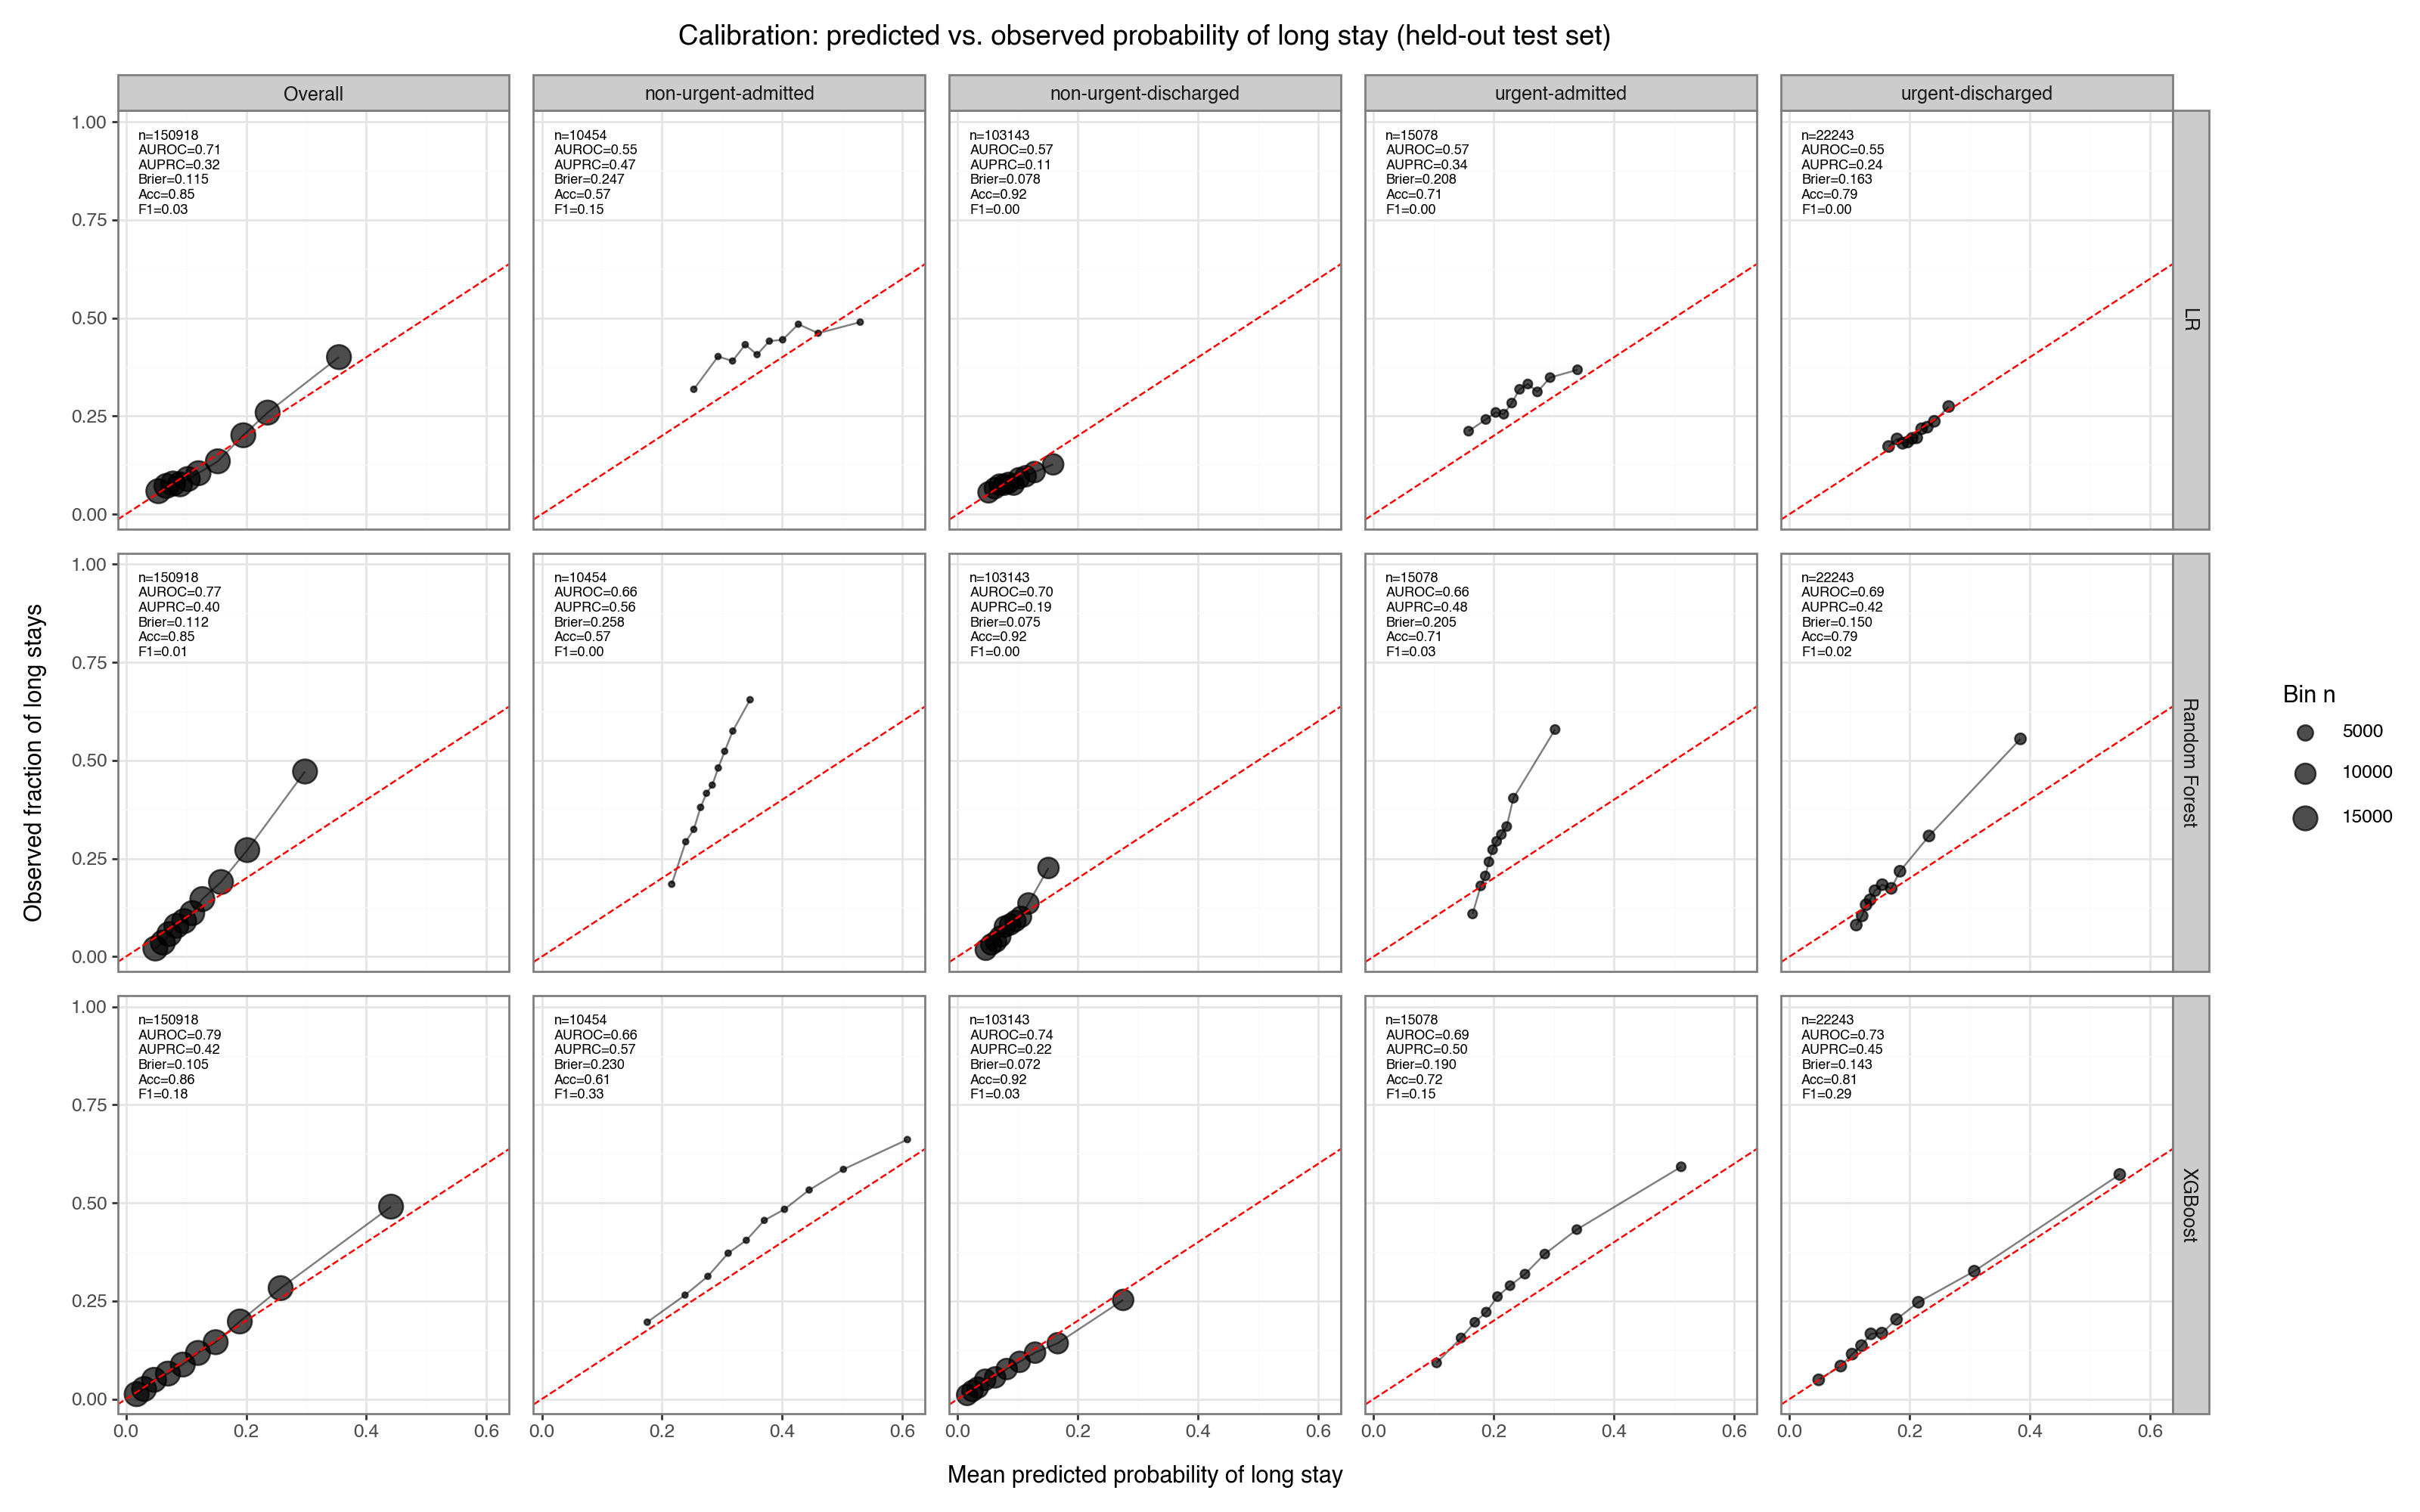

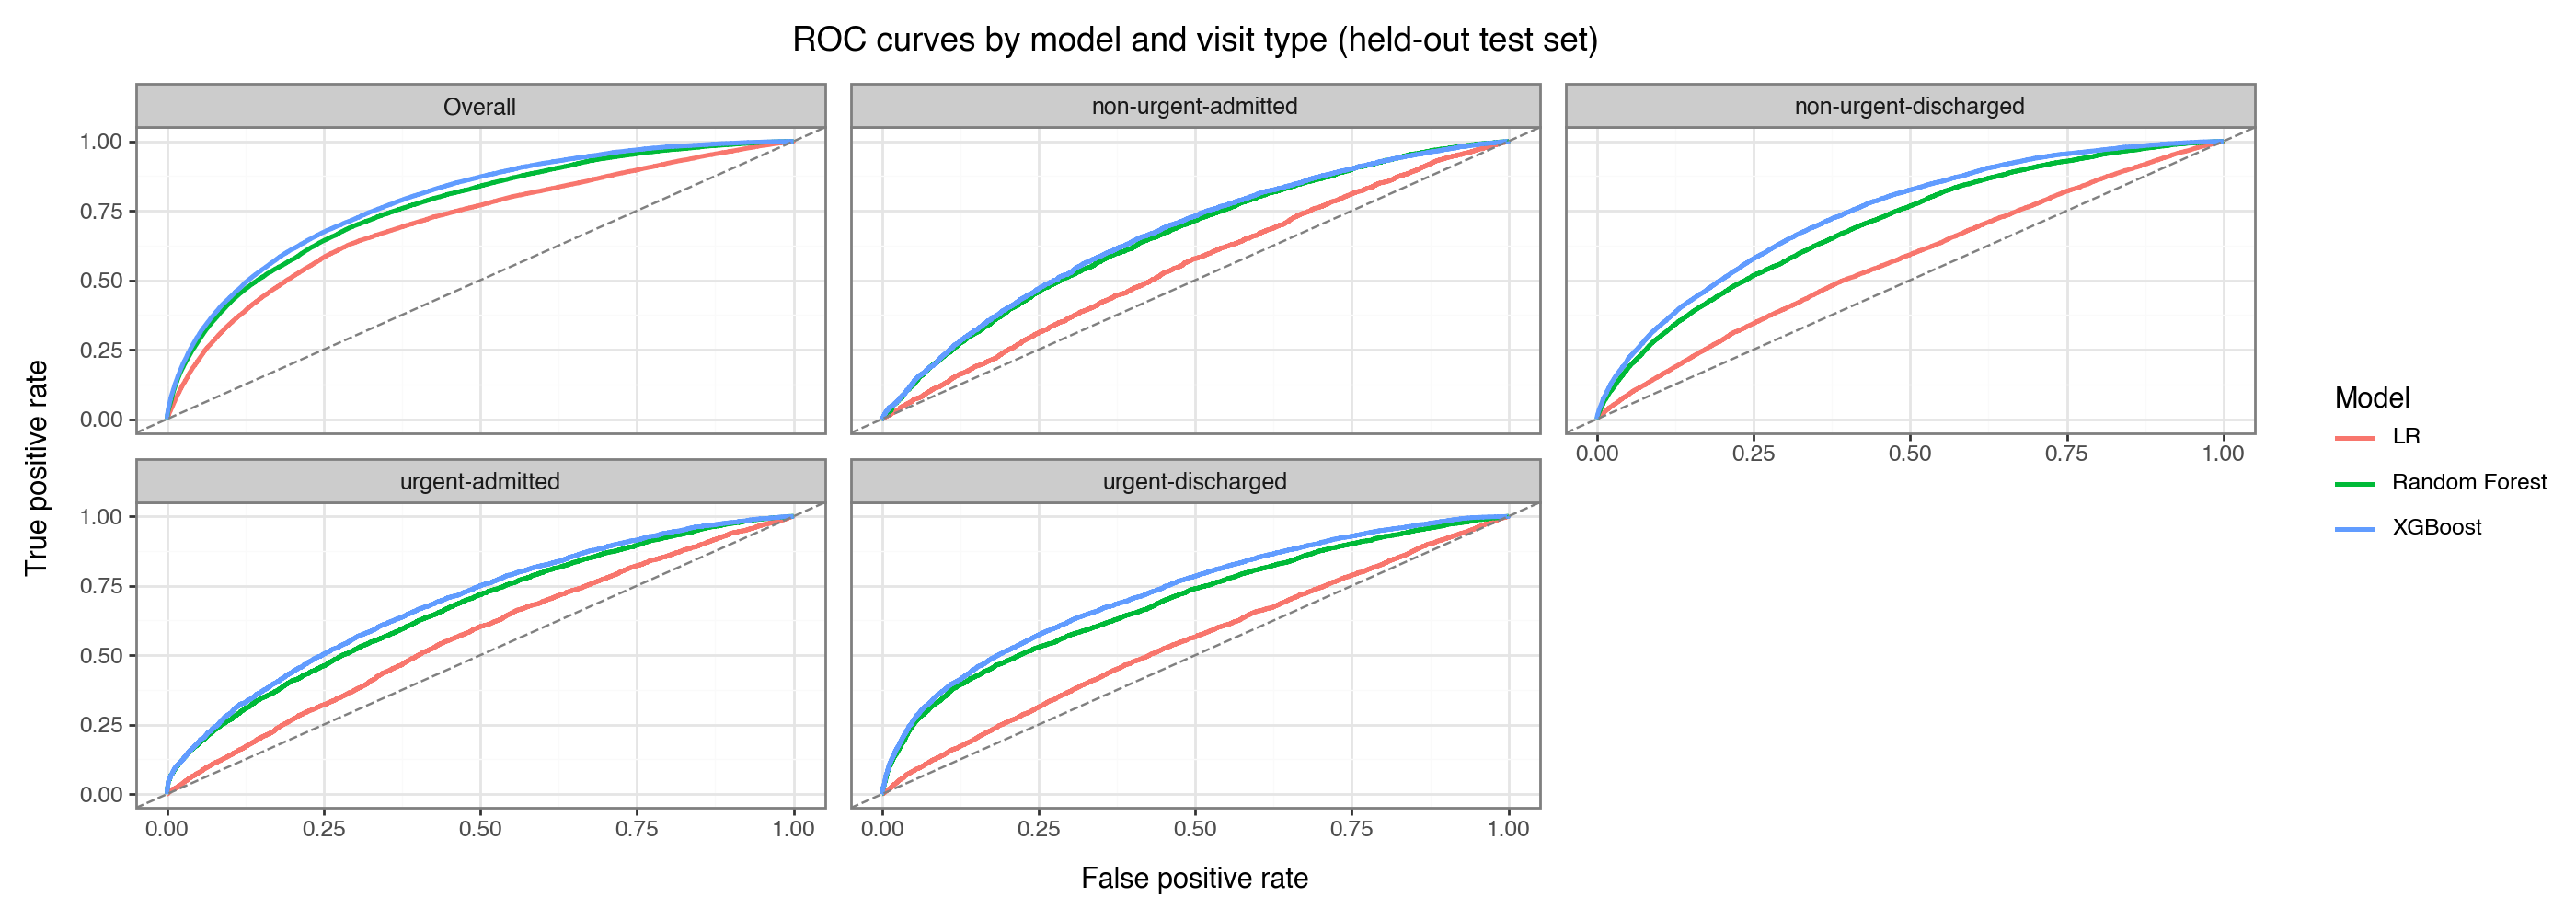

In [10]:
%matplotlib inline
import pandas as pd
import numpy as np
from plotnine import (
    ggplot, aes, geom_point, geom_line, geom_abline, geom_text,
    facet_grid, facet_wrap, labs, theme_bw, theme, element_text, scale_color_discrete
)
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    accuracy_score, f1_score, roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import statsmodels.formula.api as smf
import joblib

# ----------------------------------------------------------------------
# Load & prep data
# ----------------------------------------------------------------------
train_df = pd.read_csv(save_filepath + 'intermediate-files/ed-los-train-df.csv', index_col=0)
test_df = pd.read_csv(save_filepath + 'intermediate-files/ed-los-test-df.csv', index_col=0)

train_df['long_stay'] = (train_df['ed_los'] > long_stay_threshold).astype(int)
test_df['long_stay'] = (test_df['ed_los'] > long_stay_threshold).astype(int)

FEATURE_COLS = (['visit_type', 'non-urgent-discharged', 'urgent-admitted', 'urgent-discharged', 'non-urgent-admitted', 'is_admitted'] +
                    pre_binarised_predictors + categorical_predictors + continuous_predictors)


# One-hot encoded feature matrices for the sklearn-style models
X_train = pd.get_dummies(train_df[FEATURE_COLS], columns=['visit_type'] + categorical_predictors, drop_first=False)
X_test = pd.get_dummies(test_df[FEATURE_COLS], columns=['visit_type'] + categorical_predictors, drop_first=False)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)  # guard against unseen categories


# Binary classification target: long_stay (0/1)
y_train = train_df['long_stay']
y_test = test_df['long_stay']


# ----------------------------------------------------------------------
# Fit each model on the SAME train split, predict probabilities on train + test
# ----------------------------------------------------------------------
preds = {}  # preds[model_name] = {'train': proba_array, 'test': proba_array}

# --- Model 1: Binomial (Logistic) Regression ---
formula = "long_stay ~ visit_type * (Q('non-urgent-discharged') + Q('urgent-admitted') + Q('urgent-discharged') + Q('non-urgent-admitted'))"
logit_results = smf.logit(formula, data=train_df).fit()

preds['LR'] = {
    'train': logit_results.predict(train_df).values,
    'test': logit_results.predict(test_df).values,
}

# --- Model 2: XGBoost classifier ---
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=210226,
    n_jobs=-1, eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
preds['XGBoost'] = {
    'train': xgb_model.predict_proba(X_train)[:, 1],
    'test': xgb_model.predict_proba(X_test)[:, 1],
}

# --- Model 3: Random Forest classifier ---
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=8, random_state=210221, n_jobs=-1
)
rf_model.fit(X_train, y_train)
preds['Random Forest'] = {
    'train': rf_model.predict_proba(X_train)[:, 1],
    'test': rf_model.predict_proba(X_test)[:, 1],
}

# ----------------------------------------------------------------------
# Classification metrics
# ----------------------------------------------------------------------
def compute_metrics(y_true, y_pred_proba, threshold=0.5):
    y_true = np.asarray(y_true)
    y_pred_proba = np.asarray(y_pred_proba)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred_proba)
    y_true, y_pred_proba = y_true[mask], y_pred_proba[mask]
    y_pred_class = (y_pred_proba >= threshold).astype(int)

    if len(np.unique(y_true)) > 1:
        auroc = roc_auc_score(y_true, y_pred_proba)
        auprc = average_precision_score(y_true, y_pred_proba)
    else:
        auroc, auprc = np.nan, np.nan

    brier = brier_score_loss(y_true, y_pred_proba)
    acc = accuracy_score(y_true, y_pred_class)
    f1 = f1_score(y_true, y_pred_class, zero_division=0)

    return pd.Series({'n': mask.sum(), 'AUROC': auroc, 'AUPRC': auprc, 'Brier': brier, 'Accuracy': acc, 'F1': f1})

# ----------------------------------------------------------------------
# Build a long comparison dataframe (test set only — this is the honest
# out-of-sample comparison) with an added "Overall" pseudo-group
# ----------------------------------------------------------------------
def build_comparison_df():
    rows = []
    for model_name, p in preds.items():
        chunk = pd.DataFrame({
            'visit_type': test_df['visit_type'].values,
            'actual': y_test.values,
            'pred': p['test'],
        })
        chunk['model'] = model_name
        rows.append(chunk)
    long_df = pd.concat(rows, ignore_index=True)

    overall = long_df.copy()
    overall['visit_type'] = 'Overall'
    long_df = pd.concat([long_df, overall], ignore_index=True)
    return long_df[['model', 'visit_type', 'actual', 'pred']]

# ----------------------------------------------------------------------
# Plot 1: Calibration plot (binned predicted probability vs observed
# fraction of long stays) — this is the classification analog of the
# old predicted-vs-actual scatter, faceted the same way (model ~ visit_type)
# ----------------------------------------------------------------------
def build_calibration_df(n_bins=10):
    plot_df = build_comparison_df()
    rows = []
    for (model_name, visit_type), g in plot_df.groupby(['model', 'visit_type']):
        if g['pred'].nunique() < 2:
            continue
        g = g.copy()
        g['bin'] = pd.qcut(g['pred'], q=min(n_bins, g['pred'].nunique()), duplicates='drop')
        binned = g.groupby('bin', observed=True).agg(
            mean_pred=('pred', 'mean'),
            observed_frac=('actual', 'mean'),
            n=('actual', 'size')
        ).reset_index()
        binned['model'] = model_name
        binned['visit_type'] = visit_type
        rows.append(binned)
    return pd.concat(rows, ignore_index=True)

def plot_calibration():
    calib_df = build_calibration_df()
    plot_df = build_comparison_df()

    metrics_df = (
        plot_df.groupby(['model', 'visit_type'])
        .apply(lambda g: compute_metrics(g['actual'], g['pred']))
        .reset_index()
    )
    metrics_df['label'] = metrics_df.apply(
        lambda r: (f"n={int(r['n'])}\nAUROC={r['AUROC']:.2f}\nAUPRC={r['AUPRC']:.2f}\n"
                    f"Brier={r['Brier']:.3f}\nAcc={r['Accuracy']:.2f}\nF1={r['F1']:.2f}"),
        axis=1
    )
    metrics_df['x'] = 0.02
    metrics_df['y'] = 0.98

    p = (
        ggplot(calib_df, aes(x='mean_pred', y='observed_frac'))
        + geom_point(aes(size='n'), alpha=0.7)
        + geom_line(alpha=0.5)
        + geom_abline(slope=1, intercept=0, color='red', linetype='dashed')
        + geom_text(
            data=metrics_df,
            mapping=aes(x='x', y='y', label='label'),
            ha='left', va='top', size=6.5, color='black'
        )
        + facet_grid('model ~ visit_type')
        + labs(
            x='Mean predicted probability of long stay',
            y='Observed fraction of long stays',
            title='Calibration: predicted vs. observed probability of long stay (held-out test set)',
            size='Bin n'
        )
        + theme_bw()
        + theme(figure_size=(16, 10), strip_text=element_text(size=9))
    )
    return p

# ----------------------------------------------------------------------
# Plot 2: ROC curves, one panel per visit_type, one line per model
# ----------------------------------------------------------------------
def build_roc_df():
    plot_df = build_comparison_df()
    rows = []
    for (model_name, visit_type), g in plot_df.groupby(['model', 'visit_type']):
        if g['actual'].nunique() < 2:
            continue
        fpr, tpr, _ = roc_curve(g['actual'], g['pred'])
        rows.append(pd.DataFrame({
            'fpr': fpr, 'tpr': tpr,
            'model': model_name, 'visit_type': visit_type
        }))
    return pd.concat(rows, ignore_index=True)

def plot_roc():
    roc_df = build_roc_df()
    p = (
        ggplot(roc_df, aes(x='fpr', y='tpr', color='model'))
        + geom_line(size=1)
        + geom_abline(slope=1, intercept=0, color='grey', linetype='dashed')
        + facet_wrap('~visit_type')
        + labs(
            x='False positive rate',
            y='True positive rate',
            title='ROC curves by model and visit type (held-out test set)',
            color='Model'
        )
        + theme_bw()
        + theme(figure_size=(14, 5), strip_text=element_text(size=9))
    )
    return p

# --- Calibration plot ---
p_calibration = plot_calibration()
p_calibration.show()

# --- ROC curves ---
p_roc = plot_roc()
p_roc.show()

Have vibe-coded an LSTM:

In [12]:
"""
LSTM for ED "long stay" prediction, modeled as a causal sequence of visits
ordered by arrival time (captures crowding/queue dynamics via hidden state).

Assumptions baked into this script (adjust to your data):
  - One dataframe per site, already sorted (or sortable) by arrival time.
    If you have multiple sites, run this pipeline separately per site, or
    add a site_id categorical feature AND reset hidden state at site boundaries.
  - timestamp_col is a NUMERIC "minutes since first arrival" index, not a
    datetime. If you also know the real calendar datetime of the first
    arrival, set Config.reference_start_datetime to reconstruct hour-of-day /
    day-of-week cyclical features; otherwise those are skipped automatically.
  - Target: long_stay, a binary 0/1 flag (e.g. ed_los >= some threshold).
    Trained with a per-timestep binary cross-entropy loss on the raw logit;
    predicted probability is sigmoid(logit) at inference/eval time.
  - If your train/test frames already contain a `long_stay` column (as
    produced upstream), it's used directly. If not, and you still have the
    continuous `ed_los` column plus a threshold, set
    Config.long_stay_threshold and it will be derived automatically.
  - Retrospective setting: fine to use disposition/admission status as a
    feature, since prediction is made after discharge, not at triage.
  - categorical_predictors are TEXT/STRING categories and need explicit
    integer encoding (fit on train_df only, with an "unseen" fallback bucket
    for categories that only appear in test_df).
  - pre_binarised_predictors and is_admitted are already 0/1 binary flags -
    these are treated as NUMERIC inputs, not embedded. Embedding a 2-state
    variable adds parameters for no benefit; a raw 0/1 (or its z-score)
    already represents it fully.
  - Truncated BPTT: sequences are chunked into windows; the LSTM hidden
    state is carried across consecutive windows of the same sequence and
    detached between windows to cap the backprop graph size.

Fill in continuous_predictors / categorical_predictors / pre_binarised_predictors
and the file paths in the RUN section at the bottom, then execute.
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    accuracy_score, f1_score
)


# --------------------------------------------------------------------------
# Age banding for age-specific vital-sign normalization.
#
# Pediatric vitals (HR, RR, BP, etc.) have very different normal ranges by
# age - a heart rate that's normal for a 2-month-old is a tachycardia for a
# 10-year-old. Z-scoring across the whole population would wash that out, so
# age-dependent columns get their mean/std/median computed WITHIN each band
# instead of globally. Bin edges are in days for exact, unambiguous cutoffs.
# --------------------------------------------------------------------------
DAYS_PER_MONTH = 30.4375   # 365.25 / 12, for unambiguous month cutoffs
DAYS_PER_YEAR = 365.25

AGE_BIN_EDGES_DAYS = [
    0,
    3 * DAYS_PER_MONTH,
    6 * DAYS_PER_MONTH,
    12 * DAYS_PER_MONTH,
    18 * DAYS_PER_MONTH,
    36 * DAYS_PER_MONTH,
    5 * DAYS_PER_YEAR,
    10 * DAYS_PER_YEAR,
    15 * DAYS_PER_YEAR,
    np.inf,
]
AGE_BIN_LABELS = [
    "0-3mo", "3-6mo", "6-12mo", "12-18mo", "18-36mo",
    "3-5y", "5-10y", "10-15y", "15+",
]
UNKNOWN_AGE_GROUP = "unknown"  # fallback bucket for missing/out-of-range ages


def assign_age_group(df: pd.DataFrame, age_col: str, age_group_col: str = "age_group") -> pd.DataFrame:
    """
    Adds an age_group categorical column from a numeric age_in_days column.
    Bins are left-inclusive/right-exclusive (e.g. "0-3mo" = [0, 3mo)).
    Missing or negative/invalid ages fall back to a shared "unknown" bucket
    rather than becoming NaN, so every row still has a usable group.
    """
    df = df.copy()
    age_days = df[age_col]
    group = pd.cut(age_days, bins=AGE_BIN_EDGES_DAYS, labels=AGE_BIN_LABELS,
                    right=False, include_lowest=True)
    df[age_group_col] = group.astype(object)
    df[age_group_col] = df[age_group_col].where(age_days.notna() & (age_days >= 0), UNKNOWN_AGE_GROUP)
    df[age_group_col] = df[age_group_col].fillna(UNKNOWN_AGE_GROUP)
    return df


# --------------------------------------------------------------------------
# CONFIG - built dynamically from your predictor lists once train_df is loaded.
# Call build_config(train_df, continuous_predictors, categorical_predictors,
# pre_binarised_predictors) rather than editing a hardcoded class - see RUN
# section at the bottom.
# --------------------------------------------------------------------------
class Config:
    timestamp_col = "arrival"
    target_col = "long_stay"    # binary 0/1 classification target
    los_col = "ed_los"          # optional; only used to derive target_col if missing
    long_stay_threshold = None  # set a numeric threshold to derive target_col from los_col

    # If you know the real-world calendar datetime of the very first arrival,
    # set it here (e.g. pd.Timestamp("2021-01-04 07:12:00")) and hour-of-day /
    # day-of-week cyclical features will be reconstructed automatically.
    # Leave as None to skip those features (inter-arrival gap is still used).
    reference_start_datetime = None

    # These are populated by build_config(); placeholders here just document
    # the shape expected.
    numeric_cols = []          # continuous predictors + binary flags + is_admitted
    categorical_cols = {}      # {col: cardinality including the +1 unknown bucket}
    embedding_dims = {}        # {col: chosen embedding size, < cardinality}
    time_cols = []             # populated at feature-engineering time

    # Age-specific normalization/imputation
    age_col = "age_in_days"
    age_group_col = "age_group"
    age_dependent_cols = set()   # subset of numeric_cols normalized PER age band
    min_age_group_size = 10      # bands with fewer valid train rows fall back to global stats

    hidden_dim = 128
    lstm_layers = 2
    dropout = 0.1

    window_len = 20      # visits per truncated-BPTT window
    window_stride = 20   # non-overlapping; reduce for overlap
    batch_size = 16

    lr = 1e-3
    epochs = 20
    device = "cuda" if torch.cuda.is_available() else "cpu"

    classification_threshold = 0.5  # for accuracy/F1 reporting


def build_config(train_df, continuous_predictors, categorical_predictors,
                  pre_binarised_predictors, is_admitted_col="is_admitted",
                  timestamp_col="arrival", target_col="long_stay",
                  los_col="ed_los", long_stay_threshold=None,
                  reference_start_datetime=None,
                  age_dependent_predictors=None, age_col="age_in_days",
                  min_age_group_size=10):
    """
    Constructs a Config instance from your predictor lists.

    - continuous_predictors, pre_binarised_predictors, and is_admitted are all
      routed to numeric_cols (binary flags need no embedding).
    - categorical_predictors are TEXT columns -> get integer-encoded (see
      fit_categorical_encoders) and go through embeddings, sized well below
      their cardinality rather than equal to it.
    - target_col: binary 0/1 classification target. If it's already a column
      in train_df/test_df (the common case), it's used as-is. If it's absent
      but los_col + long_stay_threshold are given, it's derived automatically
      in add_time_and_target_features.
    - age_dependent_predictors: subset of continuous_predictors (typically
      vitals like hr/sbp/dbp/rr/spo2/temp) that should be normalized and
      imputed PER age band (see AGE_BIN_LABELS) rather than globally. Must
      already be part of continuous_predictors - pass age_in_days itself
      separately if you also want raw age as a model feature.
    """
    cfg = Config()
    cfg.timestamp_col = timestamp_col
    cfg.target_col = target_col
    cfg.los_col = los_col
    cfg.long_stay_threshold = long_stay_threshold
    cfg.reference_start_datetime = reference_start_datetime

    cfg.numeric_cols = list(continuous_predictors) + list(pre_binarised_predictors) + [is_admitted_col]

    cfg.age_col = age_col
    cfg.min_age_group_size = min_age_group_size
    cfg.age_dependent_cols = set(age_dependent_predictors or [])
    unknown_age_dependent = cfg.age_dependent_cols - set(cfg.numeric_cols)
    if unknown_age_dependent:
        raise ValueError(
            f"age_dependent_predictors {sorted(unknown_age_dependent)} are not in "
            f"continuous_predictors/pre_binarised_predictors - add them there first."
        )

    # Cardinality is set once encoders are fit (train-only) - see prepare_train_test.
    # Placeholder here; overwritten in prepare_train_test after encoding.
    cfg.categorical_cols = {col: train_df[col].nunique() + 1 for col in categorical_predictors}
    cfg.embedding_dims = {col: min(50, (n + 1) // 2) for col, n in cfg.categorical_cols.items()}

    return cfg


# --------------------------------------------------------------------------
# Categorical encoding: text -> integer codes, fit on train_df ONLY.
# Index 0 is reserved for "unseen/unknown" (categories only in test_df).
# --------------------------------------------------------------------------
def fit_categorical_encoders(train_df: pd.DataFrame, cat_col_names: list) -> dict:
    encoders = {}
    for col in cat_col_names:
        categories = sorted(train_df[col].dropna().astype(str).unique().tolist())
        encoders[col] = {cat: i + 1 for i, cat in enumerate(categories)}  # 0 reserved for unknown
    return encoders


def apply_categorical_encoders(df: pd.DataFrame, cat_col_names: list, encoders: dict) -> pd.DataFrame:
    df = df.copy()
    for col in cat_col_names:
        df[col] = df[col].astype(str).map(encoders[col]).fillna(0).astype(np.int64)
    return df


# --------------------------------------------------------------------------
# Feature engineering
#
# Split into fit_scaler (train_df only) + apply_features (any df), so
# normalization stats and outlier caps never leak from test into train.
# --------------------------------------------------------------------------
def add_time_and_target_features(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """
    Deterministic features that don't need fitting: safe to apply to any split.

    timestamp_col is a numeric minutes-since-first-arrival index (not a
    datetime). Cyclical hour-of-day / day-of-week features are only added if
    cfg.reference_start_datetime is set; otherwise cfg.time_cols stays empty
    and the model relies on inter-arrival gap alone for temporal context.

    If cfg.target_col isn't already present, it's derived from
    (cfg.los_col >= cfg.long_stay_threshold) - requires long_stay_threshold
    to be set, otherwise this raises rather than training on a silently
    wrong target.
    """
    df = df.sort_values(cfg.timestamp_col).reset_index(drop=True)

    if cfg.reference_start_datetime is not None:
        real_ts = cfg.reference_start_datetime + pd.to_timedelta(df[cfg.timestamp_col], unit="m")
        hour = real_ts.dt.hour + real_ts.dt.minute / 60.0
        df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
        df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
        dow = real_ts.dt.dayofweek
        df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
        cfg.time_cols = ["hour_sin", "hour_cos", "dow_sin"]
    else:
        cfg.time_cols = []

    # timestamp_col is already in minutes, so a simple diff gives the gap directly
    df["inter_arrival_gap"] = df[cfg.timestamp_col].diff().fillna(0)

    if cfg.target_col not in df.columns:
        if cfg.los_col in df.columns and cfg.long_stay_threshold is not None:
            df[cfg.target_col] = (df[cfg.los_col] >= cfg.long_stay_threshold).astype(np.float32)
        else:
            raise ValueError(
                f"'{cfg.target_col}' not found in dataframe, and no "
                f"(los_col, long_stay_threshold) pair was given to derive it. "
                f"Either include '{cfg.target_col}' upstream, or set "
                f"cfg.long_stay_threshold with cfg.los_col pointing at a "
                f"continuous LOS column."
            )
    else:
        df[cfg.target_col] = df[cfg.target_col].astype(np.float32)

    return df


def diagnose_missingness(df: pd.DataFrame, numeric_cols: list, target_col: str) -> None:
    """
    Prints NaN/Inf counts per numeric column and the target. Run this on
    train_df and test_df BEFORE training - an LSTM will silently produce
    NaN loss for the entire run if even one row has a missing/infinite value,
    since the hidden state carries the NaN forward through the whole sequence.
    """
    print("--- missingness / infinity check ---")
    any_found = False
    for col in numeric_cols + [target_col]:
        n_nan = df[col].isna().sum()
        n_inf = int(np.isinf(df[col].to_numpy(dtype=float, na_value=0.0)).sum())
        if n_nan or n_inf:
            any_found = True
            print(f"  {col}: {n_nan} NaN, {n_inf} Inf (of {len(df)} rows)")
    if not any_found:
        print("  none found")
    print("-------------------------------------")


def _fit_global_stats(series: pd.Series) -> dict:
    clean = series.replace([np.inf, -np.inf], np.nan)
    return {"mu": clean.mean(), "sigma": clean.std() + 1e-6, "median": clean.median()}


def _fit_age_specific_stats(train_df: pd.DataFrame, col: str, age_group_col: str,
                             min_group_size: int) -> dict:
    """
    Global stats (fallback) plus per-age-band stats for one column. A band
    with fewer than min_group_size valid (non-NaN, non-Inf) train rows is
    skipped and falls back to the global stats at apply time - protects
    against a near-empty band producing a degenerate mean/std.
    """
    global_stats = _fit_global_stats(train_df[col])
    clean = train_df[col].replace([np.inf, -np.inf], np.nan)
    by_group = {}
    for group, series in clean.groupby(train_df[age_group_col]):
        if series.notna().sum() < min_group_size:
            continue
        by_group[group] = {"mu": series.mean(), "sigma": series.std() + 1e-6, "median": series.median()}
    return {"age_dependent": True, "global": global_stats, "by_group": by_group}


def fit_scaler(train_df: pd.DataFrame, cfg: Config) -> dict:
    """
    Compute normalization stats, an imputation value, and the outlier cap
    from train_df ONLY. Median (not mean) is used for imputation since it's
    robust to the same skew/outliers the gap cap is protecting against.

    Columns in cfg.age_dependent_cols get PER-AGE-BAND mu/sigma/median
    (train_df must already have an age_group column - see assign_age_group,
    called in prepare_train_test before this runs). All other numeric
    columns, plus inter_arrival_gap, keep a single global set of stats.
    """
    stats = {}
    gap_cap = train_df["inter_arrival_gap"].quantile(0.99)
    stats["inter_arrival_gap_cap"] = gap_cap
    capped_gap = train_df["inter_arrival_gap"].clip(upper=gap_cap)

    for col in cfg.numeric_cols:
        if col in cfg.age_dependent_cols:
            stats[col] = _fit_age_specific_stats(train_df, col, cfg.age_group_col, cfg.min_age_group_size)
        else:
            stats[col] = {"age_dependent": False, "global": _fit_global_stats(train_df[col])}

    stats["inter_arrival_gap"] = {"age_dependent": False, "global": _fit_global_stats(capped_gap)}
    return stats


def apply_features(df: pd.DataFrame, cfg: Config, scaler: dict) -> pd.DataFrame:
    """
    Apply train-fit normalization/capping/imputation to any split.

    For each numeric column: infinities are treated as missing, missing
    values are imputed (with the TRAIN median - either global, or the
    row's own age band's median for age-dependent columns), and a
    same-named "<col>_missing" indicator flag is added so the model can
    still use the fact that a value was missing (often informative in
    clinical data) rather than just silently filling it in.

    Age-dependent columns (cfg.age_dependent_cols) look up mu/sigma/median
    from the row's own age_group; if that band had too few train rows (see
    min_age_group_size) or the row's age_group wasn't seen at all, it falls
    back to that column's global stats.

    Columns are assembled in dicts and joined once via pd.concat, instead of
    being inserted one at a time, to avoid DataFrame fragmentation.
    """
    df = df.copy()
    df["inter_arrival_gap"] = df["inter_arrival_gap"].clip(upper=scaler["inter_arrival_gap_cap"])

    new_cols = {}
    for col in cfg.numeric_cols + ["inter_arrival_gap"]:
        col_stats = scaler[col]
        raw = df[col].replace([np.inf, -np.inf], np.nan)
        is_missing = raw.isna()

        if col_stats["age_dependent"]:
            by_group = col_stats["by_group"]
            fallback = col_stats["global"]
            row_stats = df[cfg.age_group_col].map(lambda g: by_group.get(g, fallback))
            mu = row_stats.map(lambda s: s["mu"])
            sigma = row_stats.map(lambda s: s["sigma"])
            median = row_stats.map(lambda s: s["median"])
        else:
            mu, sigma, median = col_stats["global"]["mu"], col_stats["global"]["sigma"], col_stats["global"]["median"]

        imputed = raw.fillna(median)
        new_cols[col + "_z"] = (imputed - mu) / sigma

        # Skip a missing-indicator column for inter_arrival_gap - it's
        # already guaranteed non-null (first row is filled with 0 upstream).
        if col != "inter_arrival_gap":
            new_cols[col + "_missing"] = is_missing.astype(np.float32)

    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

    # Fail loudly here rather than silently training on NaNs for N epochs -
    # if this trips, a column exists that isn't in cfg.numeric_cols but
    # should be, or the imputation above has a gap.
    remaining_nan_cols = [c for c in new_cols if df[c].isna().any()]
    if remaining_nan_cols:
        raise ValueError(
            f"NaNs remain after imputation in columns: {remaining_nan_cols}. "
            f"Check that these columns exist and are fully numeric in both "
            f"train_df and test_df."
        )

    return df


def prepare_train_test(train_df: pd.DataFrame, test_df: pd.DataFrame, cfg: Config):
    """
    Fits categorical encoders, time features, and the numeric scaler on
    train_df only, then applies all of it identically to test_df. Also
    updates cfg.categorical_cols / cfg.embedding_dims to reflect the actual
    fit encoders (cardinality = known categories + 1 unknown bucket).

    Returns (train_df, test_df, scaler, categorical_encoders).
    """
    cat_cols = list(cfg.categorical_cols.keys())

    # Target/time features (incl. deriving long_stay if needed) must run
    # before the missingness check, so the check covers the real target.
    train_df = add_time_and_target_features(train_df, cfg)
    test_df = add_time_and_target_features(test_df, cfg)

    print("Checking train_df for missing/infinite numeric values...")
    diagnose_missingness(train_df, cfg.numeric_cols, cfg.target_col)
    print("Checking test_df for missing/infinite numeric values...")
    diagnose_missingness(test_df, cfg.numeric_cols, cfg.target_col)

    categorical_encoders = fit_categorical_encoders(train_df, cat_cols)
    # Recompute cardinality/embedding sizes from the actual fit encoders,
    # in case build_config()'s earlier nunique()-based estimate was off
    # (e.g. due to NaNs, or categories that only appear once).
    cfg.categorical_cols = {col: len(mapping) + 1 for col, mapping in categorical_encoders.items()}
    cfg.embedding_dims = {col: min(50, (n + 1) // 2) for col, n in cfg.categorical_cols.items()}

    train_df = apply_categorical_encoders(train_df, cat_cols, categorical_encoders)
    test_df = apply_categorical_encoders(test_df, cat_cols, categorical_encoders)

    if cfg.age_dependent_cols:
        train_df = assign_age_group(train_df, cfg.age_col, cfg.age_group_col)
        test_df = assign_age_group(test_df, cfg.age_col, cfg.age_group_col)

    scaler = fit_scaler(train_df, cfg)
    train_df = apply_features(train_df, cfg, scaler)
    test_df = apply_features(test_df, cfg, scaler)

    # Sanity check worth watching: how often test_df falls back to "unknown"
    for col in cat_cols:
        unseen_frac = (test_df[col] == 0).mean()
        if unseen_frac > 0.05:
            print(f"[warning] '{col}': {unseen_frac:.1%} of test_df rows are "
                  f"unseen categories (mapped to the unknown bucket). Consider "
                  f"coarser category grouping if this is high.")

    base_rate = train_df[cfg.target_col].mean()
    print(f"[info] train_df long-stay base rate: {base_rate:.1%}")

    return train_df, test_df, scaler, categorical_encoders


# --------------------------------------------------------------------------
# Dataset: chunked, chronological windows for truncated BPTT
# --------------------------------------------------------------------------
class VisitSequenceDataset(Dataset):
    def __init__(self, df: pd.DataFrame, cfg: Config):
        self.cfg = cfg
        self.cat_cols = list(cfg.categorical_cols.keys())
        self.num_cols = (
            [c + "_z" for c in cfg.numeric_cols]
            + [c + "_missing" for c in cfg.numeric_cols]
            + ["inter_arrival_gap_z"]
        )
        self.time_cols = cfg.time_cols  # [] if reference_start_datetime wasn't set

        self.cats = df[self.cat_cols].values.astype(np.int64) if self.cat_cols else np.zeros((len(df), 0), dtype=np.int64)
        self.nums = df[self.num_cols + self.time_cols].values.astype(np.float32)
        self.targets = df[cfg.target_col].values.astype(np.float32)  # binary 0/1

        n = len(df)
        self.windows = [
            (start, min(start + cfg.window_len, n))
            for start in range(0, n, cfg.window_stride)
        ]

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        start, end = self.windows[idx]
        return {
            "cats": torch.from_numpy(self.cats[start:end]),
            "nums": torch.from_numpy(self.nums[start:end]),
            "targets": torch.from_numpy(self.targets[start:end]),
        }


def collate_pad(batch):
    """Pads variable-length windows (last window in a sequence may be shorter)."""
    lengths = [b["cats"].shape[0] for b in batch]
    max_len = max(lengths)
    n_cat = batch[0]["cats"].shape[1]
    n_num = batch[0]["nums"].shape[1]

    cats = torch.zeros(len(batch), max_len, n_cat, dtype=torch.long)
    nums = torch.zeros(len(batch), max_len, n_num, dtype=torch.float32)
    targets = torch.zeros(len(batch), max_len, dtype=torch.float32)
    mask = torch.zeros(len(batch), max_len, dtype=torch.bool)

    for i, b in enumerate(batch):
        L = lengths[i]
        cats[i, :L] = b["cats"]
        nums[i, :L] = b["nums"]
        targets[i, :L] = b["targets"]
        mask[i, :L] = True

    return cats, nums, targets, mask


# --------------------------------------------------------------------------
# Model: embeddings (categorical only) + numerics -> causal LSTM -> skip -> head
# Outputs a raw logit per timestep; apply sigmoid for a probability.
# --------------------------------------------------------------------------
class LSTMLongStayClassifier(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.cat_cols = list(cfg.categorical_cols.keys())

        self.embeddings = nn.ModuleDict({
            col: nn.Embedding(cfg.categorical_cols[col], cfg.embedding_dims[col])
            for col in self.cat_cols
        })

        # numeric_cols contribute a value column AND a missing-indicator column each,
        # plus +1 for inter_arrival_gap_z, plus any time_cols
        n_num_inputs = (len(cfg.numeric_cols) * 2) + 1 + len(cfg.time_cols)
        input_dim = sum(cfg.embedding_dims.values()) + n_num_inputs

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=cfg.hidden_dim,
            num_layers=cfg.lstm_layers,
            batch_first=True,
            dropout=cfg.dropout if cfg.lstm_layers > 1 else 0.0,
        )

        # Skip connection: concat raw static features with LSTM output before the head.
        # Lets strong static predictors (triage, diagnosis) bypass the recurrent
        # bottleneck instead of being forced entirely through the hidden state.
        head_in = cfg.hidden_dim + input_dim
        self.head = nn.Sequential(
            nn.Linear(head_in, cfg.hidden_dim),
            nn.ReLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),  # raw logit, no sigmoid here (use BCEWithLogits)
        )

    def build_input(self, cats, nums):
        if self.cat_cols:
            emb = [self.embeddings[col](cats[..., i]) for i, col in enumerate(self.cat_cols)]
            x = torch.cat(emb + [nums], dim=-1)
        else:
            x = nums
        return x

    def forward(self, cats, nums, hidden=None):
        x = self.build_input(cats, nums)              # (B, T, input_dim)
        out, hidden = self.lstm(x, hidden)             # out: (B, T, hidden_dim)
        combined = torch.cat([out, x], dim=-1)         # skip connection
        logit = self.head(combined).squeeze(-1)        # (B, T) - raw logit for long_stay
        return logit, hidden


# --------------------------------------------------------------------------
# Training loop with stateful hidden-state carrying across consecutive windows
# --------------------------------------------------------------------------
def train_one_epoch(model, loader, cfg, optimizer):
    model.train()
    hidden = None
    total_loss, n_seen = 0.0, 0

    for cats, nums, targets, mask in loader:
        cats, nums, targets, mask = (
            cats.to(cfg.device), nums.to(cfg.device),
            targets.to(cfg.device), mask.to(cfg.device),
        )

        # Detach hidden state so gradients don't flow through the whole history
        # (this is what makes it "truncated" BPTT). If batch size changes on the
        # last batch, just reset hidden to None instead of carrying it.
        if hidden is not None and hidden[0].shape[1] == cats.shape[0]:
            hidden = tuple(h.detach() for h in hidden)
        else:
            hidden = None

        optimizer.zero_grad()
        logit, hidden = model(cats, nums, hidden)

        per_step_loss = F.binary_cross_entropy_with_logits(logit, targets, reduction='none')
        loss = (per_step_loss * mask).sum() / mask.sum().clamp(min=1)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * mask.sum().item()
        n_seen += mask.sum().item()

    return total_loss / max(n_seen, 1)


@torch.no_grad()
def evaluate(model, loader, cfg):
    model.eval()
    hidden = None
    all_logit, all_true = [], []

    for cats, nums, targets, mask in loader:
        cats, nums, targets, mask = (
            cats.to(cfg.device), nums.to(cfg.device),
            targets.to(cfg.device), mask.to(cfg.device),
        )
        if hidden is not None and hidden[0].shape[1] == cats.shape[0]:
            hidden = tuple(h.detach() for h in hidden)
        else:
            hidden = None

        logit, hidden = model(cats, nums, hidden)
        all_logit.append(logit[mask].cpu().numpy())
        all_true.append(targets[mask].cpu().numpy())

    logit = np.concatenate(all_logit)
    true = np.concatenate(all_true)
    proba = 1.0 / (1.0 + np.exp(-logit))  # sigmoid

    bce = np.mean(
        np.maximum(logit, 0) - logit * true + np.log1p(np.exp(-np.abs(logit)))
    )  # numerically-stable BCE, matches the training loss on the log scale

    pred_class = (proba >= cfg.classification_threshold).astype(int)
    if len(np.unique(true)) > 1:
        auroc = roc_auc_score(true, proba)
        auprc = average_precision_score(true, proba)
    else:
        auroc, auprc = np.nan, np.nan
    brier = brier_score_loss(true, proba)
    acc = accuracy_score(true, pred_class)
    f1 = f1_score(true, pred_class, zero_division=0)

    return {"bce": bce, "auroc": auroc, "auprc": auprc, "brier": brier, "accuracy": acc, "f1": f1}


# --------------------------------------------------------------------------
# Main: takes your existing chronologically-split train_df / test_df
# --------------------------------------------------------------------------
def main(train_df_raw: pd.DataFrame, test_df_raw: pd.DataFrame, cfg: Config, val_frac: float = 0.15):
    """
    train_df_raw, test_df_raw: your existing splits, each still containing the
    raw columns named in cfg (timestamp, target/LOS, numeric, categorical text
    columns). They should already be in chronological order (or at least
    each internally sortable by cfg.timestamp_col) and non-overlapping in
    time, with test_df entirely after train_df.

    val_frac: fraction carved off the END of train_df (chronologically) for
    monitoring during training. This does NOT touch test_df, so test remains
    a clean, only-looked-at-once final check.
    """
    train_df, test_df, scaler, categorical_encoders = prepare_train_test(train_df_raw, test_df_raw, cfg)

    # Carve validation off the tail of train_df, chronologically - never shuffle.
    n_train = len(train_df)
    split_point = int(n_train * (1 - val_frac))
    fit_df = train_df.iloc[:split_point]
    val_df = train_df.iloc[split_point:]

    train_ds = VisitSequenceDataset(fit_df, cfg)
    val_ds = VisitSequenceDataset(val_df, cfg)
    test_ds = VisitSequenceDataset(test_df, cfg)

    # shuffle=False is required: window order within a sequence must stay
    # chronological for the carried hidden state to mean anything.
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_pad)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_pad)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_pad)

    model = LSTMLongStayClassifier(cfg).to(cfg.device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    for epoch in range(cfg.epochs):
        train_loss = train_one_epoch(model, train_loader, cfg, optimizer)
        val_metrics = evaluate(model, val_loader, cfg)
        print(f"epoch {epoch+1:02d} | train_bce {train_loss:.4f} | "
              f"val_bce {val_metrics['bce']:.4f} | "
              f"val_auroc {val_metrics['auroc']:.3f} | "
              f"val_auprc {val_metrics['auprc']:.3f} | "
              f"val_brier {val_metrics['brier']:.4f} | "
              f"val_acc {val_metrics['accuracy']:.3f} | "
              f"val_f1 {val_metrics['f1']:.3f}")

    test_metrics = evaluate(model, test_loader, cfg)
    print("TEST:", test_metrics)
    return model, test_metrics, scaler, categorical_encoders


# --------------------------------------------------------------------------
# RUN - fill in your actual predictor lists and file paths here
# --------------------------------------------------------------------------

# Vitals that should be normalized/imputed PER AGE BAND rather than
# globally - must already be listed in continuous_predictors above.
age_dependent_predictors = ['raw_weight',
     'raw_triage_dbp', 'raw_triage_hr', 'raw_triage_pain', 'raw_triage_rr', 'raw_triage_sbp', 'raw_triage_sp_o2']

train_df = pd.read_csv(save_filepath + 'intermediate-files/ed-los-train-df.csv', index_col=0)
test_df = pd.read_csv(save_filepath + 'intermediate-files/ed-los-test-df.csv', index_col=0)

train_df['long_stay'] = (train_df['ed_los'] > long_stay_threshold).astype(int)
test_df['long_stay'] = (test_df['ed_los'] > long_stay_threshold).astype(int)


cfg = build_config(
    train_df,
    continuous_predictors=continuous_predictors,
    categorical_predictors=categorical_predictors,
    pre_binarised_predictors=pre_binarised_predictors,
    is_admitted_col="is_admitted",
    timestamp_col="arrival",     # numeric minutes-since-first-arrival
    target_col="long_stay",      # binary 0/1 - already present in these CSVs
    los_col="ed_los",            # kept only as a fallback source if target_col is missing
    long_stay_threshold=None,    # set e.g. `long_stay_threshold` if target_col isn't present
    reference_start_datetime=None,  # set to a pd.Timestamp if you know the real start time
    age_dependent_predictors=age_dependent_predictors,
    age_col="age_in_days",
)

model, test_metrics, scaler, categorical_encoders = main(train_df, test_df, cfg)

Checking train_df for missing/infinite numeric values...
--- missingness / infinity check ---
  miles_travelled: 2517 NaN, 0 Inf (of 151596 rows)
  sdi_score: 2538 NaN, 0 Inf (of 151596 rows)
  raw_weight: 6421 NaN, 0 Inf (of 151596 rows)
  raw_triage_dbp: 17737 NaN, 0 Inf (of 151596 rows)
  raw_triage_hr: 44593 NaN, 0 Inf (of 151596 rows)
  raw_triage_pain: 114197 NaN, 0 Inf (of 151596 rows)
  raw_triage_rr: 45147 NaN, 0 Inf (of 151596 rows)
  raw_triage_sbp: 17496 NaN, 0 Inf (of 151596 rows)
  raw_triage_sp_o2: 60197 NaN, 0 Inf (of 151596 rows)
-------------------------------------
Checking test_df for missing/infinite numeric values...
--- missingness / infinity check ---
  miles_travelled: 1879 NaN, 0 Inf (of 150918 rows)
  sdi_score: 1908 NaN, 0 Inf (of 150918 rows)
  raw_weight: 5650 NaN, 0 Inf (of 150918 rows)
  raw_triage_dbp: 41912 NaN, 0 Inf (of 150918 rows)
  raw_triage_hr: 43232 NaN, 0 Inf (of 150918 rows)
  raw_triage_pain: 119314 NaN, 0 Inf (of 150918 rows)
  raw_triage_r

RNN appears to work much worse for this than XGBoost does.

current best 'rmse_original_units': 191.69601 -- doubling 128-256 makes it worse (194)

Decreasing window to 100 gets us to 189 (still worse than XGBoost)
To 20 gets us to 183
To 10 gets us to 179
Eliminate dropout gets us to 178